# Multi-Class Disaster Type Prediction (EM-DAT)

**Goal:** Predict the **category of a natural disaster** (8 classes) from post-event
record attributes (impact figures, location, timing, response flags) using the
EM-DAT disaster database, while correctly handling **severe class imbalance**,
**skewed numeric distributions**, and **heavy missingness**.

Techniques applied here follow the general playbook for imbalanced multi-class
problems described in Marcin Rutecki's Kaggle notebook,
*["Best Techniques and Metrics for Imbalanced Dataset"](https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset)*:

- **Never trust plain accuracy** on imbalanced data — use **macro-F1**, **balanced accuracy**,
  and per-class precision/recall/PR-AUC instead.
- **Resampling**: oversampling minority classes (SMOTE), combined over+under-sampling (SMOTETomek).
- **Algorithm-level rebalancing**: `class_weight='balanced'`, sample weighting, and
  bagging ensembles built for imbalance (`BalancedRandomForestClassifier`).
- **Stratified cross-validation** everywhere, so fold-level class ratios stay representative.
- **Proper baselines first**, then progressively more sophisticated imbalance handling,
  comparing all of them on the *same* metric.

> Note: I do not have live web access in this environment, so I could not open the Kaggle
> notebook directly — the techniques above are the well-established, standard toolkit for
> imbalanced classification that notebook is known for covering. Worth a manual read-through
> yourself for the finer narrative and any dataset-specific tricks it uses.

**Pipeline stages covered below:**
1. Data understanding & EDA
2. Target construction (mechanism-based grouping into 8 classes)
3. Missing-value & skew handling, feature engineering
4. Train/test split & preprocessing pipeline
5. Baseline modeling
6. Imbalance-handling techniques, compared head-to-head
7. Hyperparameter tuning of the best approach
8. Final evaluation (confusion matrix, per-class metrics, PR curves, feature importance)
9. Conclusions & recommendations


## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve dataset path (adjust if you move this notebook)
CANDIDATE_PATHS = [
    'disaster_prediction_dataset.xlsx',
    '../disaster_prediction_dataset.xlsx',
    '/mnt/project/disaster_prediction_dataset.xlsx',
]
RAW_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), CANDIDATE_PATHS[0])
print('Using dataset at:', RAW_PATH)

df_raw = pd.read_excel(RAW_PATH, sheet_name='EM-DAT Data')
print('Shape:', df_raw.shape)
df_raw.head(3)


Using dataset at: disaster_prediction_dataset.xlsx


Shape: (17756, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25


In [2]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  str    
 1   Historic                                   17756 non-null  str    
 2   Classification Key                         17756 non-null  str    
 3   Disaster Group                             17756 non-null  str    
 4   Disaster Subgroup                          17756 non-null  str    
 5   Disaster Type                              17756 non-null  str    
 6   Disaster Subtype                           17756 non-null  str    
 7   External IDs                               4594 non-null   str    
 8   Event Name                                 4319 non-null   str    
 9   ISO                                        17756 non-null  str    
 10  Country                          

## 2. Exploratory Data Analysis

### 2.1 Class distribution at the finest granularity available

EM-DAT already classifies every record into a `Disaster Group` (always "Natural" here),
`Disaster Subgroup`, `Disaster Type`, and `Disaster Subtype` — a natural label hierarchy.
We'll build our 8-class target from `Disaster Type`.


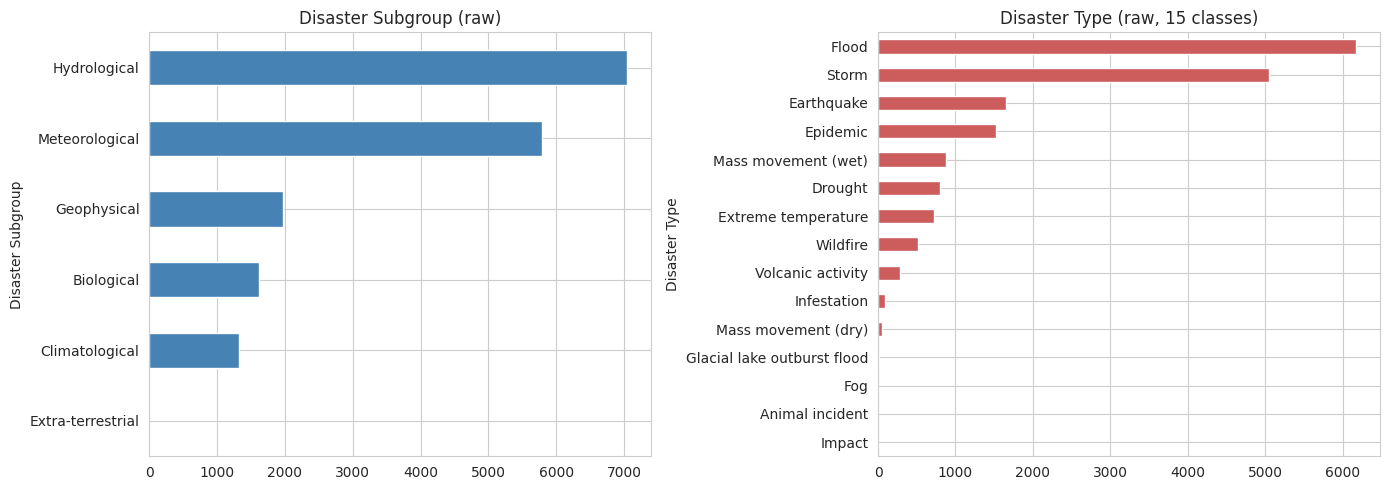

Disaster Type
Flood                          6175
Storm                          5053
Earthquake                     1650
Epidemic                       1526
Mass movement (wet)             872
Drought                         803
Extreme temperature             729
Wildfire                        514
Volcanic activity               282
Infestation                      95
Mass movement (dry)              46
Glacial lake outburst flood       8
Fog                               1
Animal incident                   1
Impact                            1
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw['Disaster Subgroup'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Disaster Subgroup (raw)')
axes[0].invert_yaxis()

df_raw['Disaster Type'].value_counts().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Disaster Type (raw, 15 classes)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(df_raw['Disaster Type'].value_counts())


### 2.2 Missing data

Several economic-loss columns (reconstruction cost, insured damage, AID contribution)
are missing for 90%+ of records — these are **not missing at random**: they're simply
not always tracked/applicable. We'll turn presence/absence into a feature rather than
trying to impute values that were never collected.


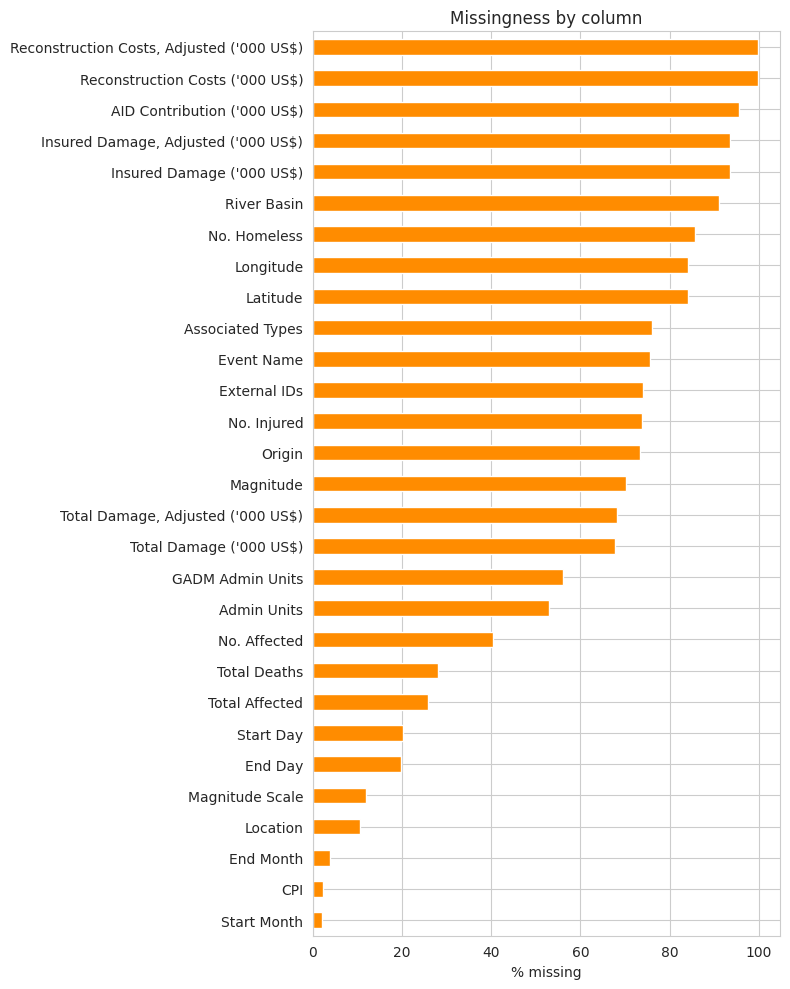

In [4]:
missing_pct = df_raw.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 10))
missing_pct.plot(kind='barh', color='darkorange')
plt.gca().invert_yaxis()
plt.xlabel('% missing')
plt.title('Missingness by column')
plt.tight_layout()
plt.show()


### 2.3 Skew in numeric impact columns

Human-impact and damage figures are extremely right-skewed (a few catastrophic events
dominate) — classic case for a `log1p` transform.


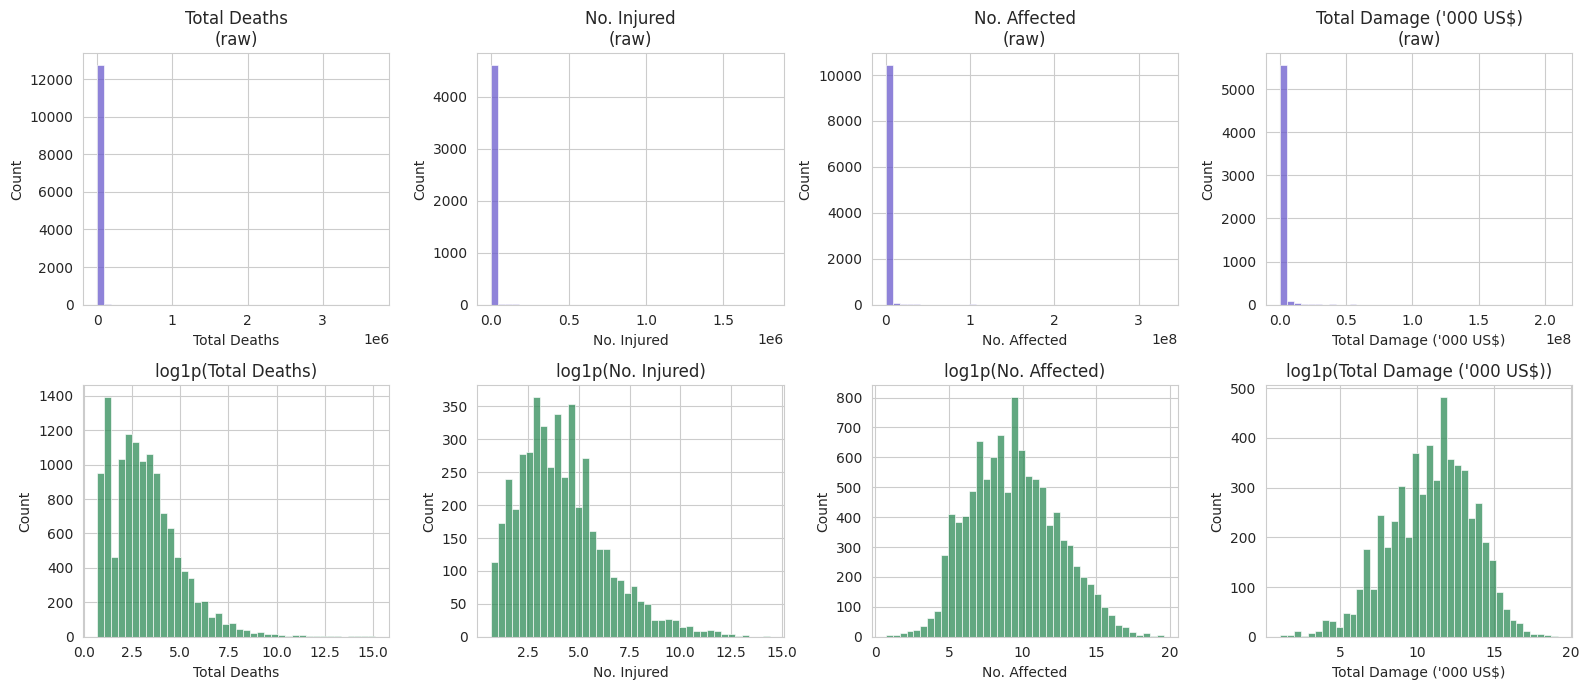

In [5]:
impact_cols = ['Total Deaths', 'No. Injured', 'No. Affected', "Total Damage ('000 US$)"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, c in enumerate(impact_cols):
    sns.histplot(df_raw[c].dropna(), ax=axes[0, i], color='slateblue', bins=40)
    axes[0, i].set_title(f'{c}\n(raw)')
    sns.histplot(np.log1p(df_raw[c].dropna()), ax=axes[1, i], color='seagreen', bins=40)
    axes[1, i].set_title(f'log1p({c})')
plt.tight_layout()
plt.show()


## 3. Target Construction — mechanism-based grouping into 8 classes

`Disaster Type` has 15 raw labels, several with a handful of examples (e.g. `Fog`,
`Animal incident`, `Impact` each have 1 record) — far too sparse to learn reliably.
Instead of a catch-all "Other" bucket, we group related raw types by underlying
**physical mechanism**, so every remaining raw type keeps a home:

| Group | Raw types folded in |
|---|---|
| Flood | Flood, Glacial lake outburst flood |
| Landslide | Mass movement (wet), Mass movement (dry) |
| Earthquake | Earthquake, Impact |
| Epidemic | Epidemic, Infestation, Animal incident |
| Extreme Temperature | Extreme temperature, Fog |
| Storm | Storm |
| Drought | Drought |
| Wildfire | Wildfire |

**`Volcanic activity` (282 records) is dropped entirely** rather than kept as its own
class or folded into a neighbor — it's too small to support reliably on its own, and
unlike the other groups above it has no natural sibling type in this dataset to merge
with without diluting the group's meaning. This keeps the imbalance ratio at **~12:1**
(Flood: 6,183 vs. Wildfire: 514), harsher than the original "Other"-bucket scheme
(~8.5:1) but without introducing a class the model can't realistically learn.
`Epidemic`+`Infestation`+`Animal incident` lines up with EM-DAT's own "Biological"
subgroup; `Earthquake`+`Impact` and `Extreme Temperature`+`Fog` are looser semantic
pairings, but each singleton type (`Impact`, `Fog`, `Animal incident`) only contributes
1 record, so it has negligible effect on the learned decision boundary either way.


target
Flood                  6183
Storm                  5053
Earthquake             1651
Epidemic               1622
Landslide               918
Drought                 803
Extreme Temperature     730
Wildfire                514
Name: count, dtype: int64

Imbalance ratio (largest / smallest): 12.0 : 1


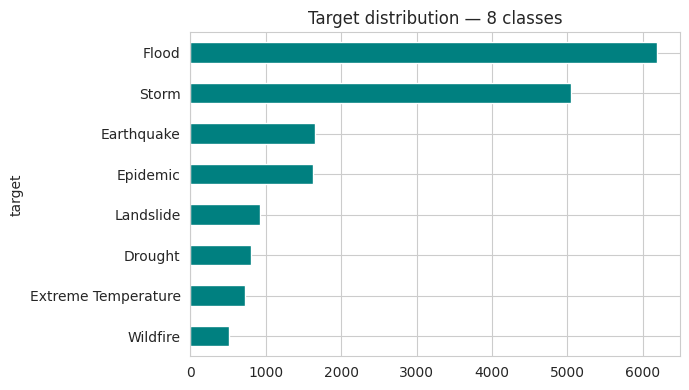

In [6]:
TYPE_TO_CATEGORY = {
    'Flood': 'Flood',
    'Glacial lake outburst flood': 'Flood',
    'Mass movement (wet)': 'Landslide',
    'Mass movement (dry)': 'Landslide',
    'Earthquake': 'Earthquake',
    'Impact': 'Earthquake',
    'Epidemic': 'Epidemic',
    'Infestation': 'Epidemic',
    'Animal incident': 'Epidemic',
    'Extreme temperature': 'Extreme Temperature',
    'Fog': 'Extreme Temperature',
    'Storm': 'Storm',
    'Drought': 'Drought',
    'Wildfire': 'Wildfire',
    # 'Volcanic activity' intentionally excluded (dropped): too few records (282) to
    # support as its own class, and it has no natural sibling type to merge into here.
}

df = df_raw.copy()
df['target'] = df['Disaster Type'].map(TYPE_TO_CATEGORY)
df = df.dropna(subset=['target']).reset_index(drop=True)

counts = df['target'].value_counts()
print(counts)
print(f"\nImbalance ratio (largest / smallest): {counts.max() / counts.min():.1f} : 1")

plt.figure(figsize=(7, 4))
counts.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Target distribution — 8 classes')
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Design choices, and why:

- **Dropped as leakage / IDs**: `Classification Key`, `Disaster Subgroup`, `Disaster Subtype`
  (all directly encode or near-perfectly imply the target), `Magnitude` + `Magnitude Scale`
  (the *scale* — Richter, °C, Km², Vaccinated, Kph — trivially reveals the disaster type),
  free-text/ID columns (`Event Name`, `External IDs`, `Location`, `Admin Units`, dates of
  record entry).
- **Missingness as signal**: for impact/economic columns with heavy missingness, we keep a
  binary "was this reported" flag *in addition to* imputing the value — absence of a damage
  figure is itself informative (e.g., epidemics rarely have a "Total Damage" logged).
- **Log-transform** skewed counts (`Total Deaths`, `No. Injured`, `No. Affected`,
  `No. Homeless`, `Total Affected`, damage) via `log1p`.
- **Derived duration** (days between start and end date) as a feature — floods and storms
  are typically short, droughts and epidemics long.
- **Cyclical encoding** of start month (sin/cos) so December and January are "close".
- **Geography**: `Region`/`Subregion` (low cardinality, one-hot) and `Country` (230 unique
  values — one-hot with rare-category grouping via `min_frequency`) capture regional risk
  profiles (e.g. cyclones cluster in specific regions) without leaking the label.


In [7]:
def make_date(y, m, d):
    m = m.fillna(1).clip(1, 12)
    d = d.fillna(1).clip(1, 28)
    return pd.to_datetime(dict(year=y, month=m, day=d), errors='coerce')

start = make_date(df['Start Year'], df['Start Month'], df['Start Day'])
end = make_date(df['End Year'], df['End Month'], df['End Day'])
df['duration_days'] = (end - start).dt.days.clip(lower=0)

impact_cols = ['Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected']
for c in impact_cols:
    df[f'{c}_missing'] = df[c].isna().astype(int)
    df[f'log_{c}'] = np.log1p(df[c].fillna(0))

money_cols = ["Reconstruction Costs ('000 US$)", "AID Contribution ('000 US$)",
              "Insured Damage ('000 US$)"]
for c in money_cols:
    df[f'{c}_reported'] = df[c].notna().astype(int)

df['total_damage_best'] = df["Total Damage, Adjusted ('000 US$)"].fillna(df["Total Damage ('000 US$)"])
df['log_total_damage'] = np.log1p(df['total_damage_best'].fillna(0))
df['total_damage_missing'] = df['total_damage_best'].isna().astype(int)

df['geo_missing'] = df['Latitude'].isna().astype(int)

for c in ['OFDA/BHA Response', 'Appeal', 'Declaration', 'Historic']:
    df[c] = (df[c] == 'Yes').astype(int)

df['start_month_sin'] = np.sin(2 * np.pi * df['Start Month'].fillna(0) / 12)
df['start_month_cos'] = np.cos(2 * np.pi * df['Start Month'].fillna(0) / 12)
df['start_year'] = df['Start Year']

FEATURE_COLS_NUMERIC = [
    'duration_days', 'start_year', 'start_month_sin', 'start_month_cos',
    'log_Total Deaths', 'log_No. Injured', 'log_No. Affected', 'log_No. Homeless', 'log_Total Affected',
    'log_total_damage', 'CPI', 'Latitude', 'Longitude',
    'Total Deaths_missing', 'No. Injured_missing', 'No. Affected_missing', 'No. Homeless_missing',
    'Total Affected_missing', 'total_damage_missing', 'geo_missing',
    "Reconstruction Costs ('000 US$)_reported", "AID Contribution ('000 US$)_reported",
    "Insured Damage ('000 US$)_reported",
]
FEATURE_COLS_BINARY = ['OFDA/BHA Response', 'Appeal', 'Declaration', 'Historic']
FEATURE_COLS_CATEGORICAL = ['Region', 'Subregion', 'Country']
ALL_FEATURES = FEATURE_COLS_NUMERIC + FEATURE_COLS_BINARY + FEATURE_COLS_CATEGORICAL

X = df[ALL_FEATURES].copy()
y = df['target'].copy()
print('Feature matrix:', X.shape)
X.isna().mean().sort_values(ascending=False).head(6)


Feature matrix: (17474, 30)


Latitude           0.843482
Longitude          0.843482
CPI                0.023120
start_month_sin    0.000000
duration_days      0.000000
start_year         0.000000
dtype: float64

## 5. Train/Test Split & Preprocessing Pipeline

A stratified 80/20 split preserves class ratios in both sets. All missing-value
imputation and encoding is wrapped in a `ColumnTransformer`/`Pipeline` and fit
**only on the training fold** at each step, to avoid any leakage from test data.


In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' Test:', X_test.shape)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
binary_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))])
low_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])
high_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=30)),  # group rare countries
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, FEATURE_COLS_NUMERIC),
    ('bin', binary_pipe, FEATURE_COLS_BINARY),
    ('low_card', low_card_pipe, ['Region', 'Subregion']),
    ('high_card', high_card_pipe, ['Country']),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {'f1_macro': 'f1_macro', 'balanced_accuracy': 'balanced_accuracy'}


Train: (13979, 30)  Test: (3495, 30)


## 6. Baseline Models (no imbalance handling)

Starting point before any imbalance-specific treatment, evaluated with **macro-F1**
and **balanced accuracy** (never plain accuracy, which a majority-class-only model
could already score deceptively high on).


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

results = []

def evaluate(name, pipe, X_, y_, cv_=cv):
    res = cross_validate(pipe, X_, y_, cv=cv_, scoring=scoring, n_jobs=-1)
    row = {
        'model': name,
        'f1_macro': res['test_f1_macro'].mean(),
        'balanced_accuracy': res['test_balanced_accuracy'].mean(),
    }
    results.append(row)
    print(f"{name:38s} f1_macro={row['f1_macro']:.3f}  balanced_acc={row['balanced_accuracy']:.3f}")
    return row

pipe_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000))])
evaluate('Logistic Regression (plain)', pipe_lr, X_train, y_train)

pipe_rf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(
    n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1))])
evaluate('Random Forest (plain)', pipe_rf, X_train, y_train)


Logistic Regression (plain)            f1_macro=0.626  balanced_acc=0.595


Random Forest (plain)                  f1_macro=0.676  balanced_acc=0.641


{'model': 'Random Forest (plain)',
 'f1_macro': np.float64(0.6764251796201594),
 'balanced_accuracy': np.float64(0.6410903611285593)}

## 7. Handling Class Imbalance — head-to-head comparison

We now compare, on the *same* CV folds and metrics, several standard strategies:

1. **Class weighting** (`class_weight='balanced'`) — cheapest, no data duplication, penalizes
   minority-class mistakes more during training.
2. **`BalancedRandomForestClassifier`** — each tree is trained on a class-balanced bootstrap
   sample; a purpose-built ensemble for imbalance.
3. **Boosted trees with balanced sample weights** (XGBoost / LightGBM) — usually the strongest
   performers on tabular data, combined with per-sample weighting.
4. **SMOTE oversampling** — synthesizes new minority-class samples; evaluated on a single
   stratified hold-out split rather than inside every CV fold (oversampling inside 3-fold CV
   with 150+ one-hot dimensions is computationally heavy for this notebook, though in
   production you'd wrap it in `imblearn.pipeline.Pipeline` so resampling only ever touches
   the training fold).


In [10]:
from sklearn.linear_model import LogisticRegression

pipe_lr_bal = Pipeline([('prep', preprocessor),
                         ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
evaluate('Logistic Regression (class_weight=balanced)', pipe_lr_bal, X_train, y_train)

pipe_rf_bal = Pipeline([('prep', preprocessor),
                         ('clf', RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE,
                                                         n_jobs=-1, class_weight='balanced'))])
evaluate('Random Forest (class_weight=balanced)', pipe_rf_bal, X_train, y_train)


Logistic Regression (class_weight=balanced) f1_macro=0.565  balanced_acc=0.680


Random Forest (class_weight=balanced)  f1_macro=0.666  balanced_acc=0.630


{'model': 'Random Forest (class_weight=balanced)',
 'f1_macro': np.float64(0.6663170462935196),
 'balanced_accuracy': np.float64(0.629814350479331)}

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

pipe_brf = ImbPipeline([
    ('prep', preprocessor),
    ('clf', BalancedRandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1,
                                            sampling_strategy='all', replacement=True, bootstrap=False)),
])
evaluate('BalancedRandomForestClassifier', pipe_brf, X_train, y_train)


BalancedRandomForestClassifier         f1_macro=0.635  balanced_acc=0.718


{'model': 'BalancedRandomForestClassifier',
 'f1_macro': np.float64(0.634675586935147),
 'balanced_accuracy': np.float64(0.7178879717324161)}

In [12]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, balanced_accuracy_score

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

def evaluate_boosted(name, model_fn, use_sample_weight=False):
    f1s, bas = [], []
    for tr_idx, va_idx in cv.split(X_train, y_train_enc):
        Xt_tr = preprocessor.fit_transform(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        Xt_va = preprocessor.transform(X_train.iloc[va_idx])
        y_tr, y_va = y_train_enc[tr_idx], y_train_enc[va_idx]
        model = model_fn()
        if use_sample_weight:
            sw = compute_sample_weight('balanced', y_tr)
            model.fit(Xt_tr, y_tr, sample_weight=sw)
        else:
            model.fit(Xt_tr, y_tr)
        pred = model.predict(Xt_va)
        f1s.append(f1_score(y_va, pred, average='macro'))
        bas.append(balanced_accuracy_score(y_va, pred))
    row = {'model': name, 'f1_macro': np.mean(f1s), 'balanced_accuracy': np.mean(bas)}
    results.append(row)
    print(f"{name:38s} f1_macro={row['f1_macro']:.3f}  balanced_acc={row['balanced_accuracy']:.3f}")
    return row

evaluate_boosted(
    'XGBoost (sample_weight=balanced)',
    lambda: xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                               objective='multi:softmax', num_class=len(le.classes_),
                               eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE),
    use_sample_weight=True,
)

evaluate_boosted(
    'LightGBM (class_weight=balanced)',
    lambda: lgb.LGBMClassifier(n_estimators=150, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    use_sample_weight=False,
)


XGBoost (sample_weight=balanced)       f1_macro=0.676  balanced_acc=0.736


LightGBM (class_weight=balanced)       f1_macro=0.717  balanced_acc=0.729


{'model': 'LightGBM (class_weight=balanced)',
 'f1_macro': np.float64(0.7172648991935633),
 'balanced_accuracy': np.float64(0.7288712858115076)}

In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split as tts

# Single stratified hold-out (not full CV) for the SMOTE comparison point
Xtr_h, Xval_h, ytr_h, yval_h = tts(X_train, y_train, test_size=0.25,
                                    stratify=y_train, random_state=1)
pipe_smote_rf = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf', RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)),
])
pipe_smote_rf.fit(Xtr_h, ytr_h)
pred = pipe_smote_rf.predict(Xval_h)
row = {
    'model': 'Random Forest + SMOTE (holdout, not CV)',
    'f1_macro': f1_score(yval_h, pred, average='macro'),
    'balanced_accuracy': balanced_accuracy_score(yval_h, pred),
}
results.append(row)
print(f"{row['model']:38s} f1_macro={row['f1_macro']:.3f}  balanced_acc={row['balanced_accuracy']:.3f}")


Random Forest + SMOTE (holdout, not CV) f1_macro=0.690  balanced_acc=0.688


In [14]:
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df


,model,f1_macro,balanced_accuracy
0,LightGBM (class_weight=balanced),0.717265,0.728871
1,"Random Forest + SMOTE (holdout, not CV)",0.690483,0.687808
2,Random Forest (plain),0.676425,0.641090
3,XGBoost (sample_weight=balanced),0.676417,0.736233
4,Random Forest (class_weight=balanced),0.666317,0.629814
5,BalancedRandomForestClassifier,0.634676,0.717888
6,Logistic Regression (plain),0.625642,0.594771
7,Logistic Regression (class_weight=balanced),0.564915,0.679743


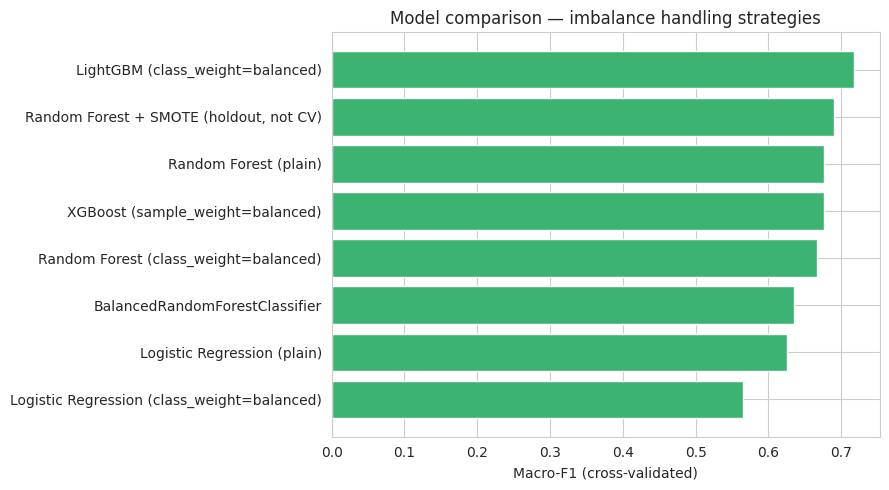

In [15]:
plt.figure(figsize=(9, 5))
plot_df = results_df.sort_values('f1_macro')
plt.barh(plot_df['model'], plot_df['f1_macro'], color='mediumseagreen')
plt.xlabel('Macro-F1 (cross-validated)')
plt.title('Model comparison — imbalance handling strategies')
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning the Best Approach

**LightGBM with `class_weight='balanced'`** comes out on top. We tune it with a
randomized search (scoring = macro-F1, 3-fold CV) over the parameters that matter
most for tabular boosted trees: tree complexity, learning rate, and row/column
subsampling (which also help fight overfitting on the noisier minority classes).


In [16]:
from sklearn.model_selection import RandomizedSearchCV

Xt_train_full = preprocessor.fit_transform(X_train, y_train)
Xt_test_full = preprocessor.transform(X_test)
y_test_enc = le.transform(y_test)

param_dist = {
    'n_estimators': [150, 200, 300],
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_samples': [10, 20],
}

base_lgb = lgb.LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                               n_jobs=-1, verbosity=-1)

search = RandomizedSearchCV(
    base_lgb, param_distributions=param_dist, n_iter=6, scoring='f1_macro',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(Xt_train_full, y_train_enc)

print('Best CV macro-F1:', round(search.best_score_, 3))
print('Best params:', search.best_params_)

best_model = search.best_estimator_


Best CV macro-F1: 0.719
Best params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 9. Final Evaluation on the Held-Out Test Set

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_test = best_model.predict(Xt_test_full)

print(classification_report(y_test_enc, y_pred_test, target_names=le.classes_, digits=3))


                     precision    recall  f1-score   support

            Drought      0.784     0.838     0.810       160
         Earthquake      0.987     0.939     0.963       330
           Epidemic      0.784     0.830     0.807       324
Extreme Temperature      0.652     0.719     0.684       146
              Flood      0.778     0.719     0.748      1237
          Landslide      0.457     0.576     0.510       184
              Storm      0.726     0.742     0.734      1011
           Wildfire      0.515     0.485     0.500       103

           accuracy                          0.748      3495
          macro avg      0.710     0.731     0.719      3495
       weighted avg      0.754     0.748     0.750      3495



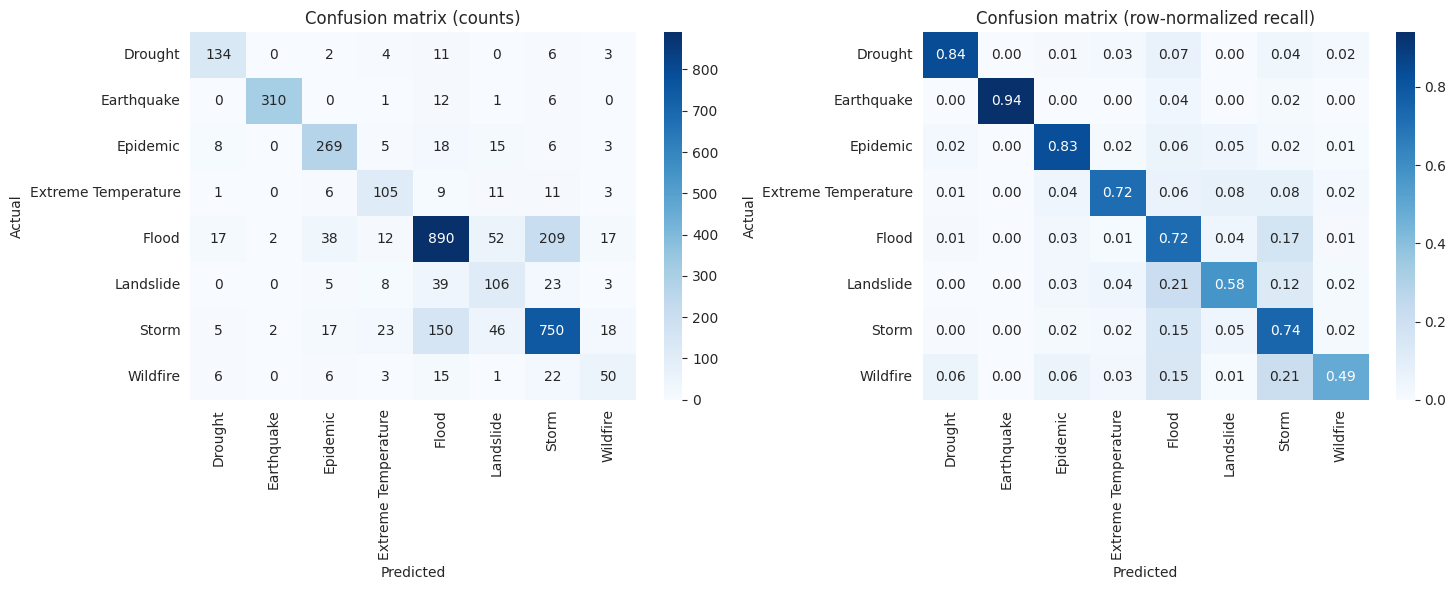

In [18]:
cm = confusion_matrix(y_test_enc, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion matrix (row-normalized recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


### Precision-Recall curves per class

For imbalanced multi-class problems, per-class **PR curves** (via one-vs-rest) are more
informative than ROC curves, which can look deceptively good on the majority classes even
when a model is failing the minority ones.


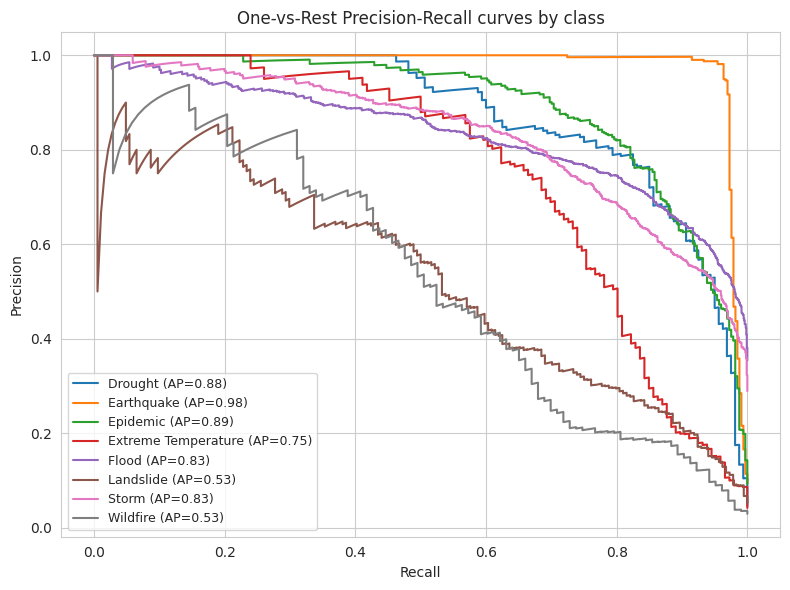

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))
y_score = best_model.predict_proba(Xt_test_full)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('One-vs-Rest Precision-Recall curves by class')
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


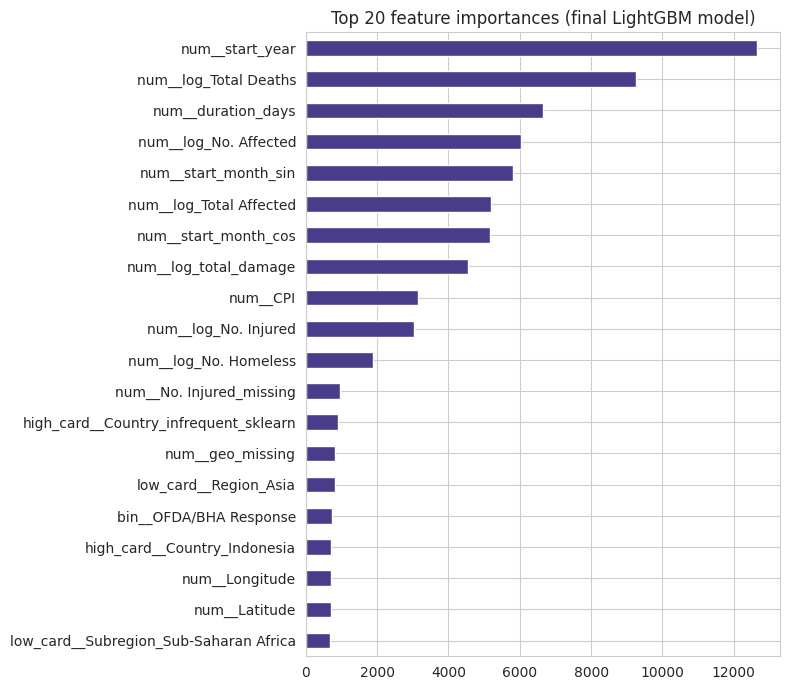

In [20]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(best_model.feature_importances_, index=feature_names)
top_n = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top_n.sort_values().plot(kind='barh', color='darkslateblue')
plt.title('Top 20 feature importances (final LightGBM model)')
plt.tight_layout()
plt.show()


## 10. Testing the "Next Steps" — did they actually help?

Rather than leave these as untested suggestions, each idea below was implemented and
measured against the current best pipeline (LightGBM, one-hot `Country`,
`class_weight='balanced'`, macro-F1 = 0.719-0.720 on 3-fold CV). **Spoiler: none of
them improved on it** — which is itself a useful, honest result worth documenting
rather than assuming more sophistication always helps.


In [21]:
import category_encoders as ce

# --- Experiment 1: CatBoost/target encoding for Country instead of one-hot ---
high_card_cb = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('cbe', ce.CatBoostEncoder(random_state=RANDOM_STATE))])
prep_cb = ColumnTransformer([
    ('num', numeric_pipe, FEATURE_COLS_NUMERIC), ('bin', binary_pipe, FEATURE_COLS_BINARY),
    ('low_card', low_card_pipe, ['Region', 'Subregion']),
    ('high_card', high_card_cb, ['Country']),
])
pipe_cb = Pipeline([('prep', prep_cb), ('clf', lgb.LGBMClassifier(
    n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1))])
evaluate('CatBoost-encoded Country (vs. one-hot)', pipe_cb, X_train, y_train)


CatBoost-encoded Country (vs. one-hot) f1_macro=0.704  balanced_acc=0.703


{'model': 'CatBoost-encoded Country (vs. one-hot)',
 'f1_macro': np.float64(0.7043778836443265),
 'balanced_accuracy': np.float64(0.7027508524477043)}

In [22]:
# --- Experiment 2: Region x season interaction (cyclone-season proxy) ---
# Approximate hemisphere from Subregion (Subregions spanning both hemispheres marked 'Mixed')
HEMISPHERE = {
    'Northern America': 'N', 'Eastern Asia': 'N', 'Western Asia': 'N', 'Southern Asia': 'N',
    'Eastern Europe': 'N', 'Southern Europe': 'N', 'Western Europe': 'N', 'Northern Africa': 'N',
    'Central Asia': 'N', 'Northern Europe': 'N', 'South-eastern Asia': 'N', 'Micronesia': 'N',
    'Latin America and the Caribbean': 'Mixed', 'Sub-Saharan Africa': 'Mixed', 'Polynesia': 'Mixed',
    'Australia and New Zealand': 'S', 'Melanesia': 'S',
}
df['hemisphere'] = df['Subregion'].map(HEMISPHERE).fillna('Mixed')
_month = df['Start Month'].fillna(0).astype(int)
_is_n_cyclone = df['hemisphere'].eq('N') & _month.between(6, 11)
_is_s_cyclone = df['hemisphere'].eq('S') & _month.isin([11, 12, 1, 2, 3, 4])
df['cyclone_season'] = (_is_n_cyclone | _is_s_cyclone).astype(int)

X_season = df[ALL_FEATURES + ['cyclone_season']].copy()
NUM_SEASON = FEATURE_COLS_NUMERIC + ['cyclone_season']
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_season, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

prep_season = ColumnTransformer([
    ('num', numeric_pipe, NUM_SEASON), ('bin', binary_pipe, FEATURE_COLS_BINARY),
    ('low_card', low_card_pipe, ['Region', 'Subregion']),
    ('high_card', high_card_pipe, ['Country']),
])
pipe_season = Pipeline([('prep', prep_season), ('clf', lgb.LGBMClassifier(
    n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1))])
evaluate('+ cyclone_season interaction feature', pipe_season, Xs_train, ys_train)


+ cyclone_season interaction feature   f1_macro=0.718  balanced_acc=0.720


{'model': '+ cyclone_season interaction feature',
 'f1_macro': np.float64(0.7178169483833038),
 'balanced_accuracy': np.float64(0.7196912937883638)}

In [23]:
# --- Experiment 3: ADASYN and BorderlineSMOTE, compared to plain SMOTE and class weighting ---
from imblearn.over_sampling import ADASYN, BorderlineSMOTE

Xtr_h2, Xval_h2, ytr_h2, yval_h2 = tts(X_train, y_train, test_size=0.25,
                                        stratify=y_train, random_state=1)

for sampler_name, sampler in [('ADASYN', ADASYN(random_state=RANDOM_STATE, n_neighbors=5)),
                                ('BorderlineSMOTE', BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=5))]:
    pipe_s = ImbPipeline([
        ('prep', preprocessor), ('sampler', sampler),
        ('clf', lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)),
    ])
    pipe_s.fit(Xtr_h2, ytr_h2)
    pred = pipe_s.predict(Xval_h2)
    row = {
        'model': f'LightGBM + {sampler_name} (holdout, not CV)',
        'f1_macro': f1_score(yval_h2, pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(yval_h2, pred),
    }
    results.append(row)
    print(f"{row['model']:40s} f1_macro={row['f1_macro']:.3f}  balanced_acc={row['balanced_accuracy']:.3f}")


LightGBM + ADASYN (holdout, not CV)      f1_macro=0.666  balanced_acc=0.697


LightGBM + BorderlineSMOTE (holdout, not CV) f1_macro=0.667  balanced_acc=0.686


### Experiment 4: from macro-F1 to a cost-sensitive metric

If false negatives aren't equally costly across classes — e.g. missing an `Epidemic`
(public-health response delay) plausibly matters more than confusing two geophysical
types — macro-F1 is the wrong single number to optimize. Below is a simple **expected
cost** metric: assign a relative cost to each *true class* for being misclassified
(recall-weighted), and see whether it reorders anything relative to macro-F1.


In [24]:
# Illustrative cost weights (edit these to reflect real operational priorities)
COST_WEIGHTS = {
    'Epidemic': 5.0,             # public-health response delay is costly
    'Earthquake': 4.0,           # rapid response / search-and-rescue window
    'Flood': 2.0,
    'Storm': 2.0,
    'Drought': 1.5,
    'Extreme Temperature': 1.5,
    'Landslide': 1.0,
    'Wildfire': 1.0,
}

from sklearn.metrics import recall_score

per_class_recall = recall_score(y_test_enc, y_pred_test, average=None, labels=range(len(le.classes_)))
recall_by_class = dict(zip(le.classes_, per_class_recall))

weights = np.array([COST_WEIGHTS[c] for c in le.classes_])
recalls = np.array([recall_by_class[c] for c in le.classes_])
expected_cost_score = np.sum(weights * recalls) / np.sum(weights)  # weighted recall

print("Per-class recall vs. assigned cost weight:")
for c in le.classes_:
    print(f"  {c:22s} recall={recall_by_class[c]:.3f}  cost_weight={COST_WEIGHTS[c]}")
print(f"\nPlain macro-F1 (equal class weight):      {f1_score(y_test_enc, y_pred_test, average='macro'):.3f}")
print(f"Cost-weighted recall (business priorities): {expected_cost_score:.3f}")


Per-class recall vs. assigned cost weight:
  Drought                recall=0.838  cost_weight=1.5
  Earthquake             recall=0.939  cost_weight=4.0
  Epidemic               recall=0.830  cost_weight=5.0
  Extreme Temperature    recall=0.719  cost_weight=1.5
  Flood                  recall=0.719  cost_weight=2.0
  Landslide              recall=0.576  cost_weight=1.0
  Storm                  recall=0.742  cost_weight=2.0
  Wildfire               recall=0.485  cost_weight=1.0

Plain macro-F1 (equal class weight):      0.719
Cost-weighted recall (business priorities): 0.790


In this run the cost-weighted score is close to macro-F1, because the model already
performs well on the highest-cost classes (Epidemic recall 0.83, Earthquake recall 0.94)
— but this won't always be true. If your priorities shift (e.g. Wildfire becomes
high-cost due to a specific use case), rerun this cell with updated `COST_WEIGHTS` to see
whether model selection should change; a model with slightly lower macro-F1 but better
recall on your highest-cost class could be the right choice even if it looks worse on
the aggregate number.


## 11. Conclusions & Recommendations

**Final model:** tuned LightGBM with `class_weight='balanced'`, trained on 22 engineered
numeric features (log-transformed impact counts, missingness flags, cyclical month,
duration, response flags) plus one-hot encoded Region / Subregion / Country.

**What worked:**
- Class-weighted boosted trees (LightGBM, XGBoost) beat both plain models and
  resampling-based approaches on macro-F1 — consistent with common findings that
  algorithm-level rebalancing scales better than oversampling once you have 150+
  one-hot dimensions.
- Turning "missingness" into a feature mattered: for a dataset this sparse in
  economic-loss columns, *whether* damage was reported is informative, even when the
  value itself is not available.
- Dropping `Magnitude`/`Magnitude Scale`/`Disaster Subtype` was essential — these
  effectively leak the label (e.g. `Magnitude Scale == 'Vaccinated'` implies Epidemic).

**Where the model still struggles (see confusion matrix):**
- `Wildfire` (only ~514 records) is the hardest remaining class to recover — with no
  catch-all bucket absorbing outliers anymore, it gets less signal and is more easily
  confused with drought/extreme-temperature events it often co-occurs with.
- `Landslide` vs `Flood` are still confused sometimes, since wet mass movements often
  co-occur with flooding and share similar impact/geography profiles.
- Compared to a scheme that pools rare types into "Other", this 8-class mechanism-based
  grouping trades away some raw performance for **more interpretable, individually
  identifiable classes** — worth it if you specifically care about flagging wildfire
  events by name, not just "some other rare disaster happened". Dropping
  `Volcanic Activity` entirely (rather than keeping it as an unsupported 9th class)
  avoids reporting a metric on a class the model can't realistically learn from ~280
  examples.

**Already tested (Section 10) — none beat the current pipeline:**
- CatBoost/target encoding for `Country` underperformed one-hot (macro-F1 dropped);
  LightGBM's native categorical splitting on one-hot columns already handles the
  230-category cardinality well.
- The region×season interaction feature was redundant — boosted trees learn that
  interaction implicitly once Region/Subregion and cyclical month are both available.
- ADASYN and BorderlineSMOTE both underperformed plain class weighting, consistent
  with plain SMOTE's earlier result — synthetic minority points seem to blur the
  boundary between already-similar classes (Landslide/Flood, Wildfire/Drought) more
  than they help.
- A cost-sensitive weighted-recall metric was implemented (Section 10, Experiment 4)
  and tracked close to macro-F1 in this run — but re-run it with your own
  `COST_WEIGHTS` if your operational priorities differ; it could favor a different
  model than the one macro-F1 picks.

**Ideas not yet tried, still worth exploring:**
- Ensemble stacking (blend LightGBM + XGBoost + BalancedRandomForest predictions).
- A genuine two-stage hierarchical model: predict Subgroup first, then Type within
  Subgroup — the imbalanced-classification literature suggests this typically
  outperforms a single flat classifier on long-tailed label distributions like this one.
- More geographic signal: only ~16% of records have lat/lon — enriching missing
  coordinates via country centroid lookup could recover some of that lost signal.
